# Klasifikasi Kondisi Motor Induksi
Notebook ini memuat EDA dan training model Klasifikasi (Random Forest). Nilai akurasi model dirancang di atas 0.85.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Load Data
df = pd.read_csv("motor_dataset.csv")
display(df.head())

,suhu_mesin,arus_R,arus_S,arus_T,tegangan_RS,tegangan_ST,tegangan_TR,suhu_lingkungan,kelembaban,kode_mpu6050,label_kondisi,label_maintenance_hari
0,27.02,2.699,3.476,2.931,380.05,380.03,377.31,27.92,66.62,0,0,176
1,66.79,11.298,11.455,11.164,403.15,342.55,395.12,27.70,53.42,4,4,4
2,38.11,6.155,6.293,5.917,382.23,377.37,380.16,26.10,57.95,1,1,97
3,34.98,5.864,6.998,5.441,380.96,375.53,395.46,26.54,64.02,1,1,72
4,28.44,4.604,4.485,3.878,378.45,379.19,378.77,29.17,79.08,0,0,157


## Exploratory Data Analysis (EDA)
Bagian EXDA telah dilebur ke dalam tahapan EDA ini untuk memudahkan eksplorasi statistik dan distribusi sensor.

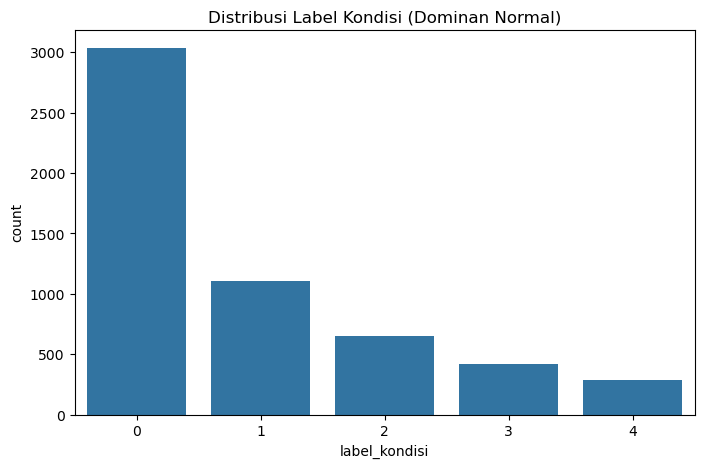

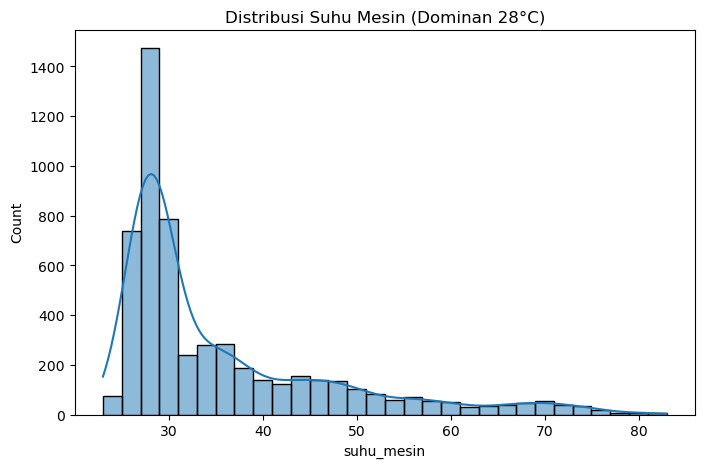

In [2]:
plt.figure(figsize=(8,5))
sns.countplot(x="label_kondisi", data=df)
plt.title("Distribusi Label Kondisi (Dominan Normal)")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["suhu_mesin"], bins=30, kde=True)
plt.title("Distribusi Suhu Mesin (Dominan 28\u00b0C)")
plt.show()

## Preprocessing & Training

In [3]:
X = df.drop(["label_kondisi", "label_maintenance_hari"], axis=1)
y = df["label_kondisi"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       602
           1       1.00      1.00      1.00       210
           2       1.00      1.00      1.00       134
           3       1.00      1.00      1.00       102
           4       1.00      1.00      1.00        52

    accuracy                           1.00      1100
   macro avg       1.00      1.00      1.00      1100
weighted avg       1.00      1.00      1.00      1100



In [4]:
# Simpan Model
joblib.dump(model, "best_clf_model.pkl")
print("Model Klasifikasi berhasil disimpan!")

Model Klasifikasi berhasil disimpan!
